In [1]:
!unzip -q dataset.zip -d CT_Data
print("Unzipping complete!")

Unzipping complete!


In [6]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

# Data Splitting
# Fixed: Added 'dataset' to the path to match the unzipped structure
data_dir = '/content/CT_Data/dataset'

# Dynamically read folder names
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
classes.sort()

filepaths, labels = [], []
for idx, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(cls_path, img_name))
            labels.append(idx)

filepaths, labels = np.array(filepaths), np.array(labels)

# 70% Train, 30% Temp -> 15% Val, 15% Test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)
print(f"Classes: {classes}")
print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Classes: ['COVID', 'non-COVID']
Train: 1736, Val: 372, Test: 373


In [7]:
class CTScanDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(CTScanDataset(train_paths, train_labels, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(CTScanDataset(val_paths, val_labels, val_test_transforms), batch_size=32, shuffle=False)
test_loader = DataLoader(CTScanDataset(test_paths, test_labels, val_test_transforms), batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers except layer4 and fc
for name, param in model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


In [8]:
epochs = 12
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs} | ", end="")
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.cpu().item())

        if phase == 'train': print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | ", end="")
        else: print(f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        if phase == 'val' and epoch_acc > best_val_acc:
            best_val_acc = epoch_acc
            torch.save(model.state_dict(), 'resnet50_covid_best.pth')

Epoch 1/12 | Train Loss: 0.4808 Acc: 0.7771 | Val Loss: 0.3006 Acc: 0.8817
Epoch 2/12 | Train Loss: 0.1710 Acc: 0.9372 | Val Loss: 0.1722 Acc: 0.9194
Epoch 3/12 | Train Loss: 0.0654 Acc: 0.9850 | Val Loss: 0.1478 Acc: 0.9435
Epoch 4/12 | Train Loss: 0.0384 Acc: 0.9931 | Val Loss: 0.1772 Acc: 0.9274
Epoch 5/12 | Train Loss: 0.0323 Acc: 0.9914 | Val Loss: 0.1479 Acc: 0.9462
Epoch 6/12 | Train Loss: 0.0165 Acc: 0.9977 | Val Loss: 0.1493 Acc: 0.9462
Epoch 7/12 | Train Loss: 0.0124 Acc: 0.9971 | Val Loss: 0.1472 Acc: 0.9597
Epoch 8/12 | Train Loss: 0.0062 Acc: 0.9983 | Val Loss: 0.1715 Acc: 0.9516
Epoch 9/12 | Train Loss: 0.0091 Acc: 0.9977 | Val Loss: 0.0977 Acc: 0.9624
Epoch 10/12 | Train Loss: 0.0090 Acc: 0.9983 | Val Loss: 0.0884 Acc: 0.9570
Epoch 11/12 | Train Loss: 0.0067 Acc: 0.9988 | Val Loss: 0.1120 Acc: 0.9704
Epoch 12/12 | Train Loss: 0.0037 Acc: 0.9988 | Val Loss: 0.1074 Acc: 0.9624


--- Classification Report ---
              precision    recall  f1-score   support

       COVID       0.98      0.97      0.97       188
   non-COVID       0.97      0.98      0.97       185

    accuracy                           0.97       373
   macro avg       0.97      0.97      0.97       373
weighted avg       0.97      0.97      0.97       373

Binary AUC-ROC: 0.9929


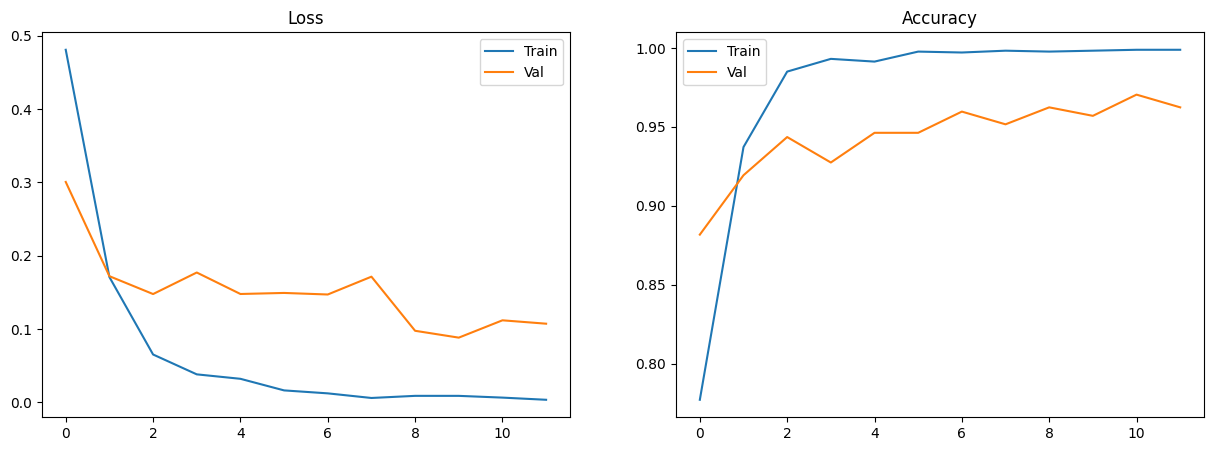

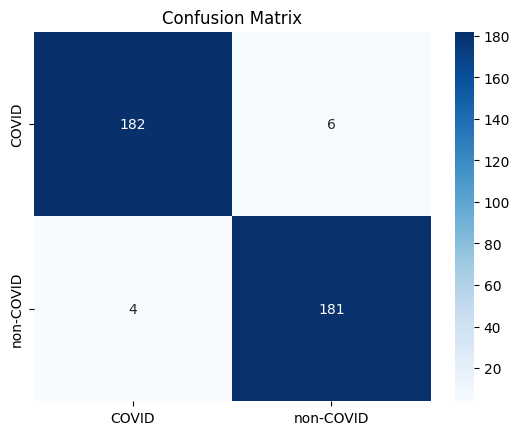

In [9]:
model.load_state_dict(torch.load('resnet50_covid_best.pth'))
model.eval()

test_preds, test_trues, test_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        # For binary AUC, we use probabilities of the positive class
        test_probs.extend(probs[:, 1].cpu().numpy())
        test_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
        test_trues.extend(labels.numpy())

print("--- Classification Report ---")
print(classification_report(test_trues, test_preds, target_names=classes))
print(f"Binary AUC-ROC: {roc_auc_score(test_trues, test_probs):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history['train_loss'], label='Train'), axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'), axes[0].legend()
axes[1].plot(history['train_acc'], label='Train'), axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'), axes[1].legend()
plt.show()

cm = confusion_matrix(test_trues, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.show()